## Task 3: Clustering Analysis (K-Means)

#### Load Dataset

In [1]:
import pandas as pd

df = pd.read_csv("churn-bigml-80.csv")

print(df.head())
print(df.info())

  State  Account length  Area code International plan Voice mail plan  \
0    KS             128        415                 No             Yes   
1    OH             107        415                 No             Yes   
2    NJ             137        415                 No              No   
3    OH              84        408                Yes              No   
4    OK              75        415                Yes              No   

   Number vmail messages  Total day minutes  Total day calls  \
0                     25              265.1              110   
1                     26              161.6              123   
2                      0              243.4              114   
3                      0              299.4               71   
4                      0              166.7              113   

   Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
0             45.07              197.4               99             16.78   
1             27.47   

#### Select Numerical Features Only

In [2]:
# Select only numeric columns
X = df.select_dtypes(include=['int64', 'float64'])

print(X.head())

   Account length  Area code  Number vmail messages  Total day minutes  \
0             128        415                     25              265.1   
1             107        415                     26              161.6   
2             137        415                      0              243.4   
3              84        408                      0              299.4   
4              75        415                      0              166.7   

   Total day calls  Total day charge  Total eve minutes  Total eve calls  \
0              110             45.07              197.4               99   
1              123             27.47              195.5              103   
2              114             41.38              121.2              110   
3               71             50.90               61.9               88   
4              113             28.34              148.3              122   

   Total eve charge  Total night minutes  Total night calls  \
0             16.78                

#### Standardize Data

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#### The dataset was standardized using StandardScaler to ensure all features contribute equally to the clustering process and to eliminate scale bias.

#### Elbow Method

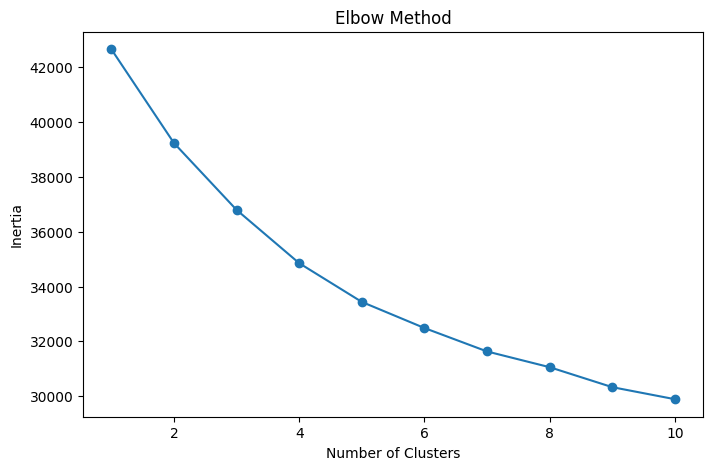

In [4]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

#### The Elbow Method was used to determine the optimal number of clusters. The curve shows a clear elbow point at k = 3, indicating that 3 clusters provide the best balance between model complexity and performance.

#### K-Means

In [5]:
kmeans = KMeans(n_clusters=3, random_state=42) 
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

#### 2D scatter plots

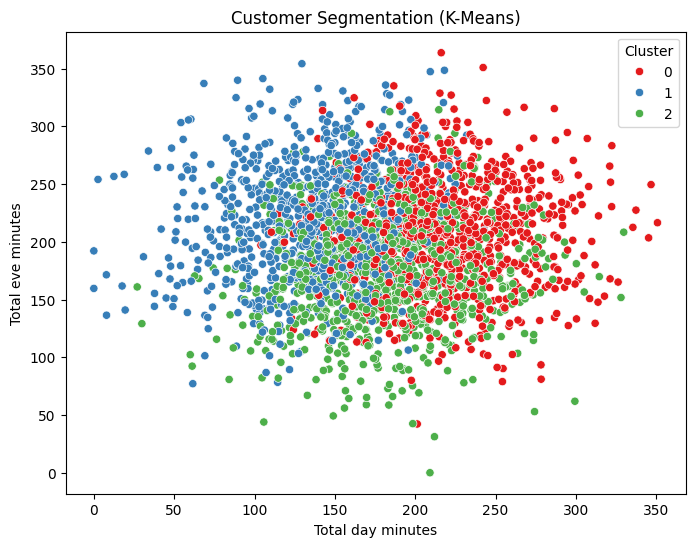

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Total day minutes'],
    y=df['Total eve minutes'],
    hue=df['Cluster'],
    palette='Set1'
)

plt.title("Customer Segmentation (K-Means)")
plt.show()

#### This graph shows the result of customer segmentation using K-Means based on total day minutes and total evening minutes.

The model divides customers into 3 clusters:

Cluster 0 (Red): Customers with higher day usage and relatively high evening usage. These can be considered heavy users.

Cluster 1 (Blue): Customers with lower day usage but still quite active in the evening.

Cluster 2 (Green): Customers with moderate to lower usage overall.

Even though there is some overlap between clusters (which is normal in K-Means), we can still see clear grouping patterns.


#### Overall Clustering Interpretation

K-Means clustering was applied to segment customers based on their call usage behavior.
The Elbow Method indicated that 3 clusters were optimal.
The resulting clusters represent distinct customer groups with different usage intensities.

#### Business Insights:
Cluster 0 represents low-usage customers.

Cluster 1 represents moderate-usage customers.

Cluster 2 represents high-usage customers.

This segmentation can help telecom companies design targeted marketing strategies, personalized offers, and retention campaigns.